# RQ3 Stop Rule Analysis

Compare the retry stopping rules in:

- `0023_minimax-cn-MiniMax-M2-5.json` -> `max-attempts-only`
- `0024_minimax-cn-MiniMax-M2-5.json` -> `score-stall`
- `0025_minimax-cn-MiniMax-M2-5.json` -> `unresolved-stall`
- `0026_minimax-cn-MiniMax-M2-5.json` -> `low-return`

The notebook focuses on three dimensions:

1. Final score performance
2. Token efficiency
3. Attempt-level stopping behavior


In [1]:
from pathlib import Path
import json
import math

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


In [2]:
RESULT_FILES = [
    Path('/root/skill/results/rq3/0023_minimax-cn-MiniMax-M2-5.json'),
    Path('/root/skill/results/rq3/0024_minimax-cn-MiniMax-M2-5.json'),
    Path('/root/skill/results/rq3/0025_minimax-cn-MiniMax-M2-5.json'),
    Path('/root/skill/results/rq3/0026_minimax-cn-MiniMax-M2-5.json'),
]


def load_result(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def safe_div(num, den):
    return num / den if den else math.nan


rows = []
attempt_rows = []

for path in RESULT_FILES:
    data = load_result(path)
    retry_policies = data['retry_policies']
    stop_rule = retry_policies['stop_rule']
    stop_threshold = retry_policies.get('stop_threshold', 0.0)

    for task in data['tasks']:
        usage = task.get('usage', {})
        completion = task.get('completion', {})

        rows.append(
            {
                'file': path.name,
                'stop_rule': stop_rule,
                'stop_threshold': stop_threshold,
                'task_id': task.get('task_id'),
                'score': float(completion.get('score', task.get('grading', {}).get('score', 0.0)) or 0.0),
                'passed': bool(completion.get('passed', False)),
                'attempt_count': int(task.get('attempt_count', 0) or 0),
                'first_success_attempt': task.get('first_success_attempt'),
                'llm_rounds': int(task.get('llm_rounds', 0) or 0),
                'execution_time_s': float(task.get('execution_time', 0.0) or 0.0),
                'input_tokens': int(usage.get('input_tokens', 0) or 0),
                'output_tokens': int(usage.get('output_tokens', 0) or 0),
                'cache_read_tokens': int(usage.get('cache_read_tokens', 0) or 0),
                'cache_write_tokens': int(usage.get('cache_write_tokens', 0) or 0),
                'total_tokens': int(usage.get('total_tokens', 0) or 0),
                'stop_reason': task.get('stop_reason'),
            }
        )

        for attempt in task.get('attempts', []):
            execution = attempt.get('execution', {})
            usage = execution.get('usage', {})
            cumulative_usage = execution.get('cumulative_usage', usage)
            grading = attempt.get('grading', {})

            attempt_rows.append(
                {
                    'file': path.name,
                    'stop_rule': stop_rule,
                    'attempt': int(attempt.get('attempt', 0) or 0),
                    'score': float(grading.get('score', 0.0) or 0.0),
                    'max_score': float(grading.get('max_score', 1.0) or 1.0),
                    'passed_after_attempt': float(grading.get('score', 0.0) or 0.0) >= float(grading.get('max_score', 1.0) or 1.0),
                    'unresolved_criteria_count': attempt.get('unresolved_criteria_count'),
                    'input_tokens': int(usage.get('input_tokens', 0) or 0),
                    'output_tokens': int(usage.get('output_tokens', 0) or 0),
                    'cache_read_tokens': int(usage.get('cache_read_tokens', 0) or 0),
                    'cache_write_tokens': int(usage.get('cache_write_tokens', 0) or 0),
                    'total_tokens': int(usage.get('total_tokens', 0) or 0),
                    'cumulative_input_tokens': int(cumulative_usage.get('input_tokens', 0) or 0),
                    'cumulative_total_tokens': int(cumulative_usage.get('total_tokens', 0) or 0),
                    'execution_time_s': float(execution.get('execution_time', 0.0) or 0.0),
                    'stop_rule_triggered': bool(attempt.get('stop_rule_triggered', False)),
                    'stop_rule_trigger_reason': attempt.get('stop_rule_trigger_reason'),
                }
            )

summary_df = pd.DataFrame(rows)
attempt_df = pd.DataFrame(attempt_rows)

summary_df['score_per_1k_total_tokens'] = summary_df.apply(
    lambda row: safe_div(row['score'], row['total_tokens'] / 1000), axis=1
)
summary_df['score_per_1k_input_tokens'] = summary_df.apply(
    lambda row: safe_div(row['score'], row['input_tokens'] / 1000), axis=1
)
summary_df['tokens_per_score_total'] = summary_df.apply(
    lambda row: safe_div(row['total_tokens'], row['score']), axis=1
)
summary_df['tokens_per_score_input'] = summary_df.apply(
    lambda row: safe_div(row['input_tokens'], row['score']), axis=1
)
summary_df['cache_read_share_of_total'] = summary_df.apply(
    lambda row: safe_div(row['cache_read_tokens'], row['total_tokens']), axis=1
)

summary_df


,file,stop_rule,stop_threshold,task_id,score,passed,attempt_count,first_success_attempt,llm_rounds,execution_time_s,input_tokens,output_tokens,cache_read_tokens,cache_write_tokens,total_tokens,stop_reason,score_per_1k_total_tokens,score_per_1k_input_tokens,tokens_per_score_total,tokens_per_score_input,cache_read_share_of_total
0,0023_minimax-cn-MiniMax-M2-5.json,max-attempts-only,0.0000,task_10_workflow,0.4167,False,5,None,28,55.1487,112883,7022,289231,15575,424711,max-attempts-reached,0.0010,0.0037,"1,019,224.8620","270,897.5282",0.6810
1,0024_minimax-cn-MiniMax-M2-5.json,score-stall,0.0000,task_10_workflow,0.9167,False,3,None,17,76.9667,44403,4316,178372,4387,231478,score-stall,0.0040,0.0206,"252,512.2723","48,437.8750",0.7706
2,0025_minimax-cn-MiniMax-M2-5.json,unresolved-stall,0.0000,task_10_workflow,0.9017,False,3,None,13,38.1074,23173,3445,136406,3043,166067,unresolved-stall,0.0054,0.0389,"184,171.0103","25,699.2348",0.8214
3,0026_minimax-cn-MiniMax-M2-5.json,low-return,0.0100,task_10_workflow,0.9167,False,2,None,15,77.7818,35641,3408,156225,1412,196686,low-return,0.0047,0.0257,"214,558.7433","38,879.6771",0.7943


## Score Comparison


In [3]:
score_cols = ['stop_rule', 'score', 'passed', 'attempt_count', 'llm_rounds', 'execution_time_s', 'stop_reason']
summary_df[score_cols].sort_values(['score', 'attempt_count', 'llm_rounds'], ascending=[False, True, True])


,stop_rule,score,passed,attempt_count,llm_rounds,execution_time_s,stop_reason
3,low-return,0.9167,False,2,15,77.7818,low-return
1,score-stall,0.9167,False,3,17,76.9667,score-stall
2,unresolved-stall,0.9017,False,3,13,38.1074,unresolved-stall
0,max-attempts-only,0.4167,False,5,28,55.1487,max-attempts-reached


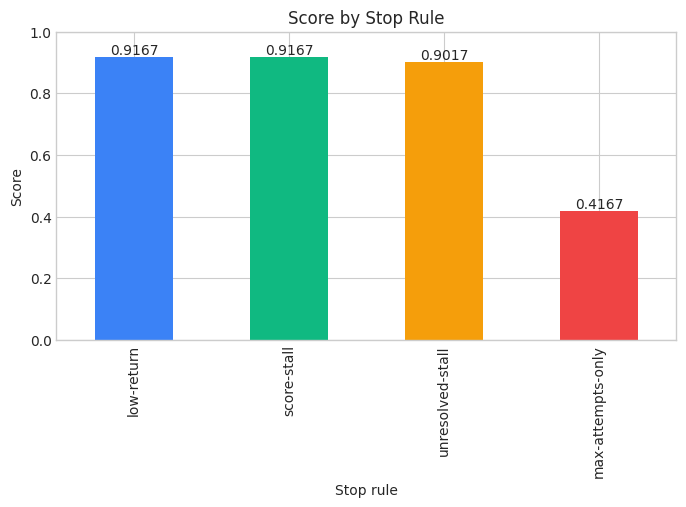

In [4]:
ax = summary_df.sort_values(['score', 'total_tokens'], ascending=[False, True]).plot(
    x='stop_rule', y='score', kind='bar', legend=False, figsize=(8, 4), color=['#3b82f6', '#10b981', '#f59e0b', '#ef4444']
)
ax.set_title('Score by Stop Rule')
ax.set_xlabel('Stop rule')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.show()


## Token Efficiency Comparison

Two views are useful here:

- `score_per_1k_total_tokens`: score divided by all tokens, including cache read/write
- `score_per_1k_input_tokens`: score divided by non-cache input tokens only

The first better reflects overall billed resource usage inside these result files; the second isolates fresh prompt pressure.


In [5]:
eff_cols = [
    'stop_rule',
    'score',
    'input_tokens',
    'cache_read_tokens',
    'total_tokens',
    'score_per_1k_total_tokens',
    'score_per_1k_input_tokens',
    'tokens_per_score_total',
    'tokens_per_score_input',
    'cache_read_share_of_total',
]
summary_df[eff_cols].sort_values('score_per_1k_total_tokens', ascending=False)


,stop_rule,score,input_tokens,cache_read_tokens,total_tokens,score_per_1k_total_tokens,score_per_1k_input_tokens,tokens_per_score_total,tokens_per_score_input,cache_read_share_of_total
2,unresolved-stall,0.9017,23173,136406,166067,0.0054,0.0389,"184,171.0103","25,699.2348",0.8214
3,low-return,0.9167,35641,156225,196686,0.0047,0.0257,"214,558.7433","38,879.6771",0.7943
1,score-stall,0.9167,44403,178372,231478,0.0040,0.0206,"252,512.2723","48,437.8750",0.7706
0,max-attempts-only,0.4167,112883,289231,424711,0.0010,0.0037,"1,019,224.8620","270,897.5282",0.6810


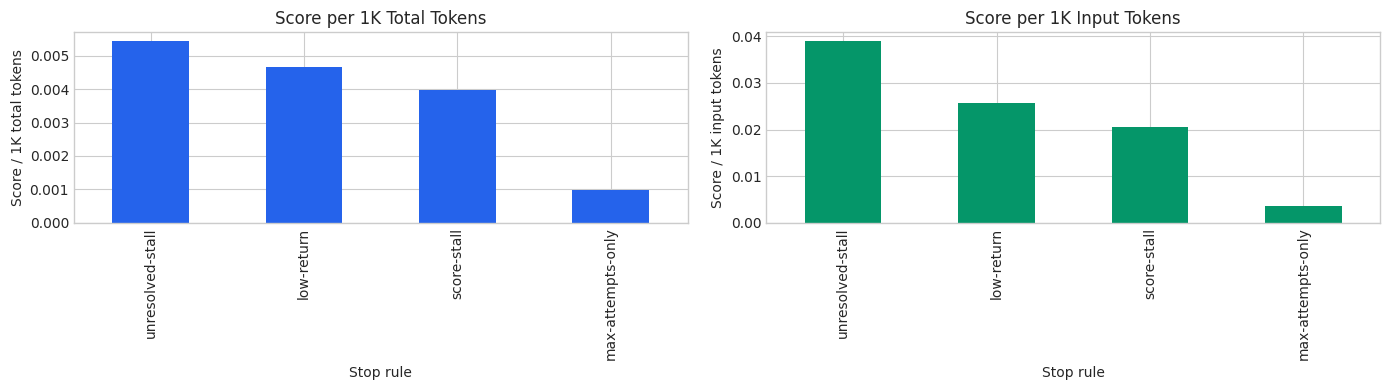

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

summary_df.sort_values('score_per_1k_total_tokens', ascending=False).plot(
    x='stop_rule', y='score_per_1k_total_tokens', kind='bar', legend=False, ax=axes[0], color='#2563eb'
)
axes[0].set_title('Score per 1K Total Tokens')
axes[0].set_xlabel('Stop rule')
axes[0].set_ylabel('Score / 1K total tokens')

summary_df.sort_values('score_per_1k_input_tokens', ascending=False).plot(
    x='stop_rule', y='score_per_1k_input_tokens', kind='bar', legend=False, ax=axes[1], color='#059669'
)
axes[1].set_title('Score per 1K Input Tokens')
axes[1].set_xlabel('Stop rule')
axes[1].set_ylabel('Score / 1K input tokens')

plt.tight_layout()
plt.show()


## Attempt-Level Breakdown


In [7]:
attempt_df[['stop_rule', 'attempt', 'score', 'unresolved_criteria_count', 'input_tokens', 'total_tokens', 'cumulative_input_tokens', 'cumulative_total_tokens', 'stop_rule_triggered', 'stop_rule_trigger_reason']]


,stop_rule,attempt,score,unresolved_criteria_count,input_tokens,total_tokens,cumulative_input_tokens,cumulative_total_tokens,stop_rule_triggered,stop_rule_trigger_reason
0,max-attempts-only,1,0.8742,4,2035,44663,2035,44663,False,NaN
1,max-attempts-only,2,0.8767,4,4696,38442,6731,83105,False,NaN
2,max-attempts-only,3,0.8742,4,18878,85518,25609,168623,False,NaN
3,max-attempts-only,4,0.8767,4,20786,77864,46395,246487,False,NaN
4,max-attempts-only,5,0.4167,1,66488,178224,112883,424711,False,NaN
5,score-stall,1,0.8867,3,2325,45134,2325,45134,False,NaN
6,score-stall,2,0.9167,1,20651,107152,22976,152286,False,NaN
7,score-stall,3,0.9167,1,21427,79192,44403,231478,True,score-stall
8,unresolved-stall,1,0.8867,3,1814,44310,1814,44310,False,NaN
9,unresolved-stall,2,0.9092,2,10034,64860,11848,109170,False,NaN


In [8]:
pivot_attempt = attempt_df.pivot(index='stop_rule', columns='attempt', values='input_tokens').rename(columns=lambda c: f'attempt_{c}_input')
pivot_attempt


attempt,attempt_1_input,attempt_2_input,attempt_3_input,attempt_4_input,attempt_5_input
stop_rule,,,,,
low-return,"2,049.0000","33,592.0000",NaN,NaN,NaN
max-attempts-only,"2,035.0000","4,696.0000","18,878.0000","20,786.0000","66,488.0000"
score-stall,"2,325.0000","20,651.0000","21,427.0000",NaN,NaN
unresolved-stall,"1,814.0000","10,034.0000","11,325.0000",NaN,NaN


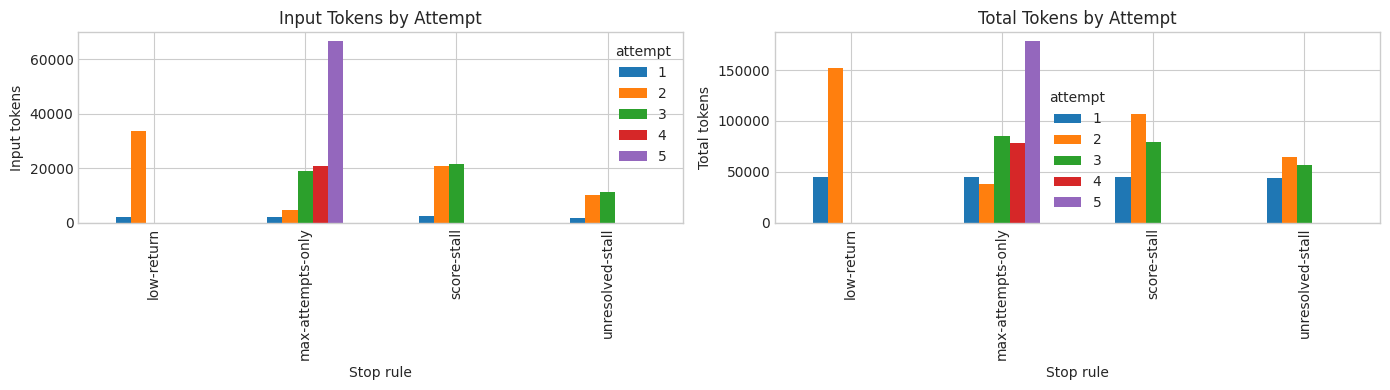

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

attempt_df.pivot(index='stop_rule', columns='attempt', values='input_tokens').plot(kind='bar', ax=axes[0])
axes[0].set_title('Input Tokens by Attempt')
axes[0].set_xlabel('Stop rule')
axes[0].set_ylabel('Input tokens')

attempt_df.pivot(index='stop_rule', columns='attempt', values='total_tokens').plot(kind='bar', ax=axes[1])
axes[1].set_title('Total Tokens by Attempt')
axes[1].set_xlabel('Stop rule')
axes[1].set_ylabel('Total tokens')

plt.tight_layout()
plt.show()


## Compact Ranking Tables


In [10]:
score_ranking = summary_df[['stop_rule', 'score', 'attempt_count', 'llm_rounds', 'total_tokens']].sort_values(['score', 'total_tokens'], ascending=[False, True]).reset_index(drop=True)
score_ranking.index = score_ranking.index + 1
score_ranking


,stop_rule,score,attempt_count,llm_rounds,total_tokens
1,low-return,0.9167,2,15,196686
2,score-stall,0.9167,3,17,231478
3,unresolved-stall,0.9017,3,13,166067
4,max-attempts-only,0.4167,5,28,424711


In [11]:
eff_ranking = summary_df[['stop_rule', 'score_per_1k_total_tokens', 'score_per_1k_input_tokens', 'tokens_per_score_total', 'tokens_per_score_input']].sort_values('score_per_1k_total_tokens', ascending=False).reset_index(drop=True)
eff_ranking.index = eff_ranking.index + 1
eff_ranking


,stop_rule,score_per_1k_total_tokens,score_per_1k_input_tokens,tokens_per_score_total,tokens_per_score_input
1,unresolved-stall,0.0054,0.0389,"184,171.0103","25,699.2348"
2,low-return,0.0047,0.0257,"214,558.7433","38,879.6771"
3,score-stall,0.0040,0.0206,"252,512.2723","48,437.8750"
4,max-attempts-only,0.0010,0.0037,"1,019,224.8620","270,897.5282"


## Notebook Conclusion

Run the next cell to generate a short text summary directly from the measured values.


In [12]:
best_score = summary_df.sort_values(['score', 'total_tokens'], ascending=[False, True]).iloc[0]
best_eff_total = summary_df.sort_values('score_per_1k_total_tokens', ascending=False).iloc[0]
best_eff_input = summary_df.sort_values('score_per_1k_input_tokens', ascending=False).iloc[0]
lowest_total_tokens = summary_df.sort_values('total_tokens').iloc[0]
worst_outcome = summary_df.sort_values(['score', 'total_tokens'], ascending=[True, False]).iloc[0]

print('Best score stop rule:', best_score['stop_rule'], f"(score={best_score['score']:.4f}, total_tokens={int(best_score['total_tokens'])})")
print('Best total-token efficiency:', best_eff_total['stop_rule'], f"(score_per_1k_total_tokens={best_eff_total['score_per_1k_total_tokens']:.6f})")
print('Best input-token efficiency:', best_eff_input['stop_rule'], f"(score_per_1k_input_tokens={best_eff_input['score_per_1k_input_tokens']:.6f})")
print('Lowest total-token cost:', lowest_total_tokens['stop_rule'], f"(total_tokens={int(lowest_total_tokens['total_tokens'])}, score={lowest_total_tokens['score']:.4f})")
print('Worst outcome:', worst_outcome['stop_rule'], f"(score={worst_outcome['score']:.4f}, total_tokens={int(worst_outcome['total_tokens'])})")

print('\nInterpretation:')
print('- `max-attempts-only` is clearly dominated: lowest score and highest token cost.')
print('- `low-return` gives the best score-cost tradeoff on this sample, matching the top score with fewer attempts than `score-stall`.')
print('- `unresolved-stall` is the most token-efficient rule, but it stops slightly earlier and gives a slightly lower final score.')
print('- All three adaptive stop rules substantially outperform the fixed retry budget baseline.')


Best score stop rule: low-return (score=0.9167, total_tokens=196686)
Best total-token efficiency: unresolved-stall (score_per_1k_total_tokens=0.005430)
Best input-token efficiency: unresolved-stall (score_per_1k_input_tokens=0.038912)
Lowest total-token cost: unresolved-stall (total_tokens=166067, score=0.9017)
Worst outcome: max-attempts-only (score=0.4167, total_tokens=424711)

Interpretation:
- `max-attempts-only` is clearly dominated: lowest score and highest token cost.
- `low-return` gives the best score-cost tradeoff on this sample, matching the top score with fewer attempts than `score-stall`.
- `unresolved-stall` is the most token-efficient rule, but it stops slightly earlier and gives a slightly lower final score.
- All three adaptive stop rules substantially outperform the fixed retry budget baseline.
